# Explore LOF anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## Score to df

In [4]:
def score_arr_to_df(score_path, bin_idx_to_specobjid):

    score_name = score_path.split("/")[-1][:-4]
    objids_bin = bin_idx_to_specobjid[:, 1]

    print(f"Loading score: {score_name}")
    raw_score = {'neg_lof': np.load(score_path)}

    score_df = pd.DataFrame(data=raw_score, index=objids_bin)
    score_df.index.name = 'specobjid'

    return score_df

## LOF histogram

In [30]:
def lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5)):

    top_1_thresholds = scores_df_dict[bin_id]['lof'].quantile(0.99)

    fig, ax = plt.subplots(
        1,1,
        figsize=figsize
    )

    _ = ax.hist(
        scores_df_dict[bin_id]['lof'], 
        bins=n_bins,
        color='tab:blue', edgecolor='black',
        linewidth=0.5
    )
    ax.set_yscale('log')
    ax.set_ylim(y_lim)
    # Formatting
    ax.minorticks_on()

    ax.axvline(
        x=top_1_thresholds,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds:.4f} '
    )

    ax.legend(frameon=False, loc='upper right')

    ax.set_ylabel('Count', fontsize=10)

    x_label = f"LOF score"
    title = f"LOF score distribution for bin {int(bin_id.split('_')[-1])+1}"
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_title(title, fontsize=12)

    return fig, ax


# Config

## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## Scaled latent per bin

In [7]:
latent_bin_dict = {}
scaled_latent_bin_dict = {}

for bin_id in bins_ids:

    latent = np.load(
        f"{latent_dir}/{bin_id}/latent_{bin_id}.npy"
    )
    scaled_latent = standard_scaler(latent)

    latent_bin_dict[bin_id] = latent
    scaled_latent_bin_dict[bin_id] = scaled_latent 

## LOF models per bin
The consensus-based strategy made LOF models winners to have
```python
n=60 and metric='manhattan'
```

```python
# save negative oulier fator for each bin
n = 60
metric = 'manhattan'
lof_model_dict = {}
neg_outlier_factor_dict = {}

for bin_id in bins_ids:

    load_from = os.path.join(
        latent_dir, bin_id,
        f'lof_{bin_id}_n{n}_{metric}.joblib'
    )

    model = joblib.load(load_from)
    lof_model_dict[bin_id] = model
  
    raw_score = model.negative_outlier_factor_
    neg_outlier_factor_dict[bin_id] = raw_score
    
    np.save(
       f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
       raw_score
    )
```

# LOF scores

## Max norm and ranking
```python
# save to local
n = 60
metric = 'manhattan'

for bin_id in bins_ids:

    bin_idx_to_specobjid = np.load(
        f"{spectra_dir}/"
        f"{bin_id}/{bin_id}_index_specobjid.npy"
    )
    
    score_df = score_arr_to_df(
        f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
        bin_idx_to_specobjid
    )

    min_neg_score = score_df['neg_lof'].min()
    
    score_df['lof'] = score_df['neg_lof'] / min_neg_score
    rank = score_df['lof'].rank(method='min', ascending=False)
    score_df['rank'] = rank.astype(int)

    score_df.to_csv(
        f"{latent_dir}/{bin_id}/"
        f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index=True
    )
```

In [9]:
scores_df_dict = {}
lof_model_dict = {}
n = 60
metric = 'manhattan'
for bin_id in bins_ids:
    # load df of scores
    scores_df_dict[bin_id] = pd.read_csv(
        f"{latent_dir}/{bin_id}/"
        f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index_col='specobjid'
    )
    # load models
    load_from = os.path.join(
        latent_dir, bin_id,
        f'lof_{bin_id}_n{n}_{metric}.joblib'
    )

    model = joblib.load(load_from)
    lof_model_dict[bin_id] = model

In [10]:
scores_df_dict[bin_id].head()

,neg_lof,lof,rank
specobjid,,,
1437819582281705472,-1.287100,0.421060,5345
1792473383787587584,-1.010198,0.330475,151899
1566270578824865792,-0.982660,0.321466,176984
1833056640966879232,-1.057616,0.345987,94097
2824940385879484416,-1.033950,0.338245,121883


In [11]:
bin_id = 'bin_03'
scores_df_dict[bin_id].sort_values(by='lof', ascending=False).head()

,neg_lof,lof,rank
specobjid,,,
969534273977608192,-3.056807,1.000000,1
2930814289679771648,-2.913354,0.953071,2
2245159102839810048,-2.851112,0.932709,3
1071977423131666432,-2.731193,0.893479,4
1919783100783552512,-2.624299,0.858510,5


# Score distributions

## bin_03

In [ ]:
bin_id = 'bin_03'

top_1_thresholds = scores_df_dict[bin_id]['lof'].quantile(0.99)
print("Score thresholds for the Top 1% of anomalies:")
print(top_1_thresholds)

print("-" * 40)

print("Score deciles:")
scores_df_dict[bin_id]['lof'].describe(
    percentiles=np.linspace(0.1, 0.9, 9)
)

Score thresholds for the Top 1% of anomalies:
0.4486573419000001
----------------------------------------
Score deciles:


count    181850.000000
mean          0.353875
std           0.027754
min           0.312122
10%           0.327018
20%           0.332220
30%           0.336852
40%           0.341655
50%           0.346969
60%           0.353185
70%           0.360901
80%           0.371577
90%           0.389536
max           1.000000
Name: lof, dtype: float64

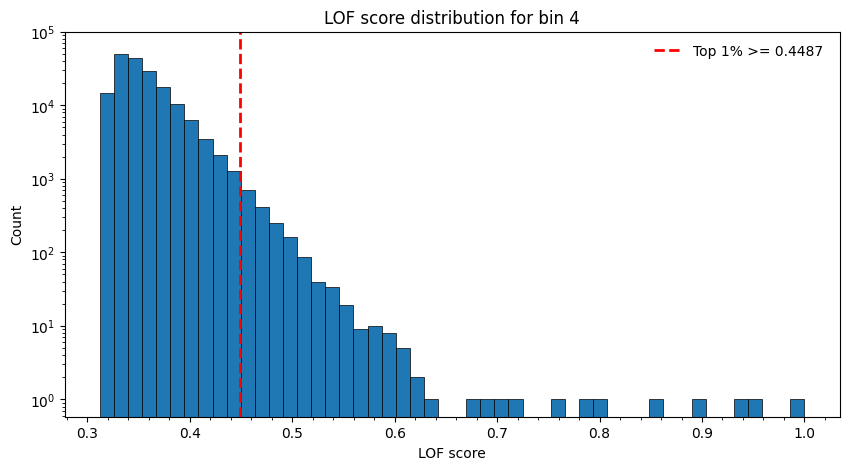

In [32]:
bin_id = 'bin_03'
_ = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'_n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_02

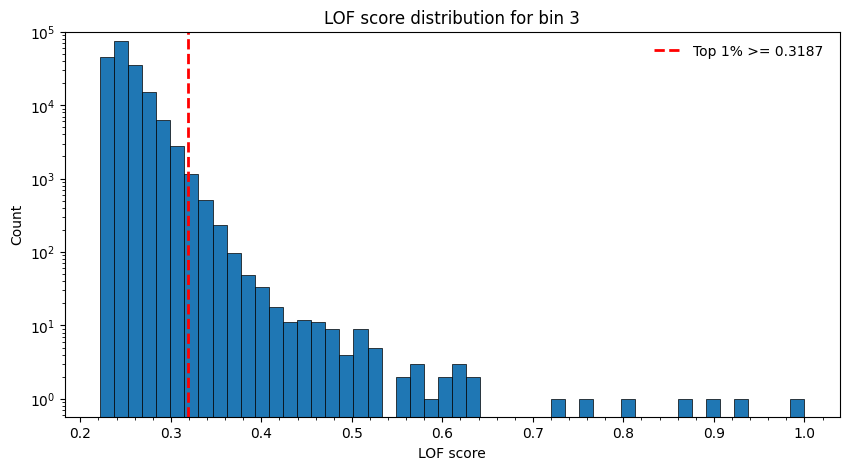

In [33]:
bin_id = 'bin_02'
_ = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'_n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_01

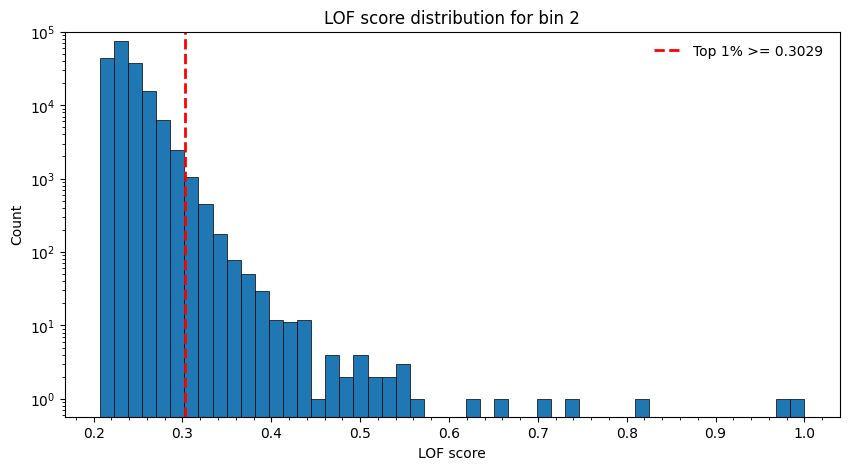

In [34]:
bin_id = 'bin_01'
_ = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'_n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_00

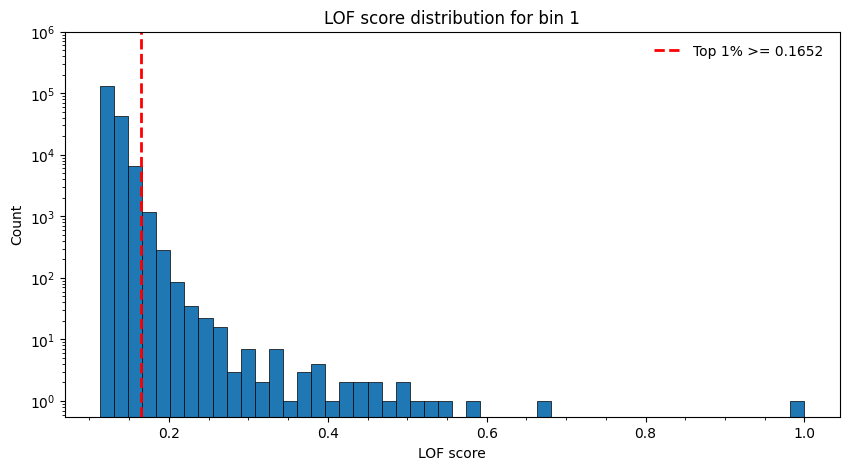

In [38]:
bin_id = 'bin_00'
_ = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e6), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'_n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)